In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df=pd.read_csv("fifa_ranking_2022-10-06.csv")
df.head(10)

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46
5,Italy,ITA,UEFA,6,7,1726.14,1713.86
6,Spain,ESP,UEFA,7,6,1715.22,1716.93
7,Netherlands,NED,UEFA,8,8,1694.51,1679.41
8,Portugal,POR,UEFA,9,9,1676.56,1678.65
9,Denmark,DEN,UEFA,10,10,1666.57,1665.47


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             211 non-null    object 
 1   team_code        211 non-null    object 
 2   association      211 non-null    object 
 3   rank             211 non-null    int64  
 4   previous_rank    211 non-null    int64  
 5   points           211 non-null    float64
 6   previous_points  211 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.7+ KB


In [6]:
df.describe()

,rank,previous_rank,points,previous_points
count,211.00000,211.00000,211.000000,211.000000
mean,106.00000,106.00000,1220.687346,1220.645592
std,61.05462,61.05462,253.420954,253.331712
min,1.00000,1.00000,762.220000,763.820000
25%,53.50000,53.50000,1007.675000,1008.330000
50%,106.00000,106.00000,1192.090000,1183.900000
75%,158.50000,158.50000,1433.465000,1431.790000
max,211.00000,211.00000,1841.300000,1837.560000


In [7]:
df.shape

(211, 7)

In [8]:
df.columns

Index(['team', 'team_code', 'association', 'rank', 'previous_rank', 'points',
       'previous_points'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

Ranking Overview Analysis

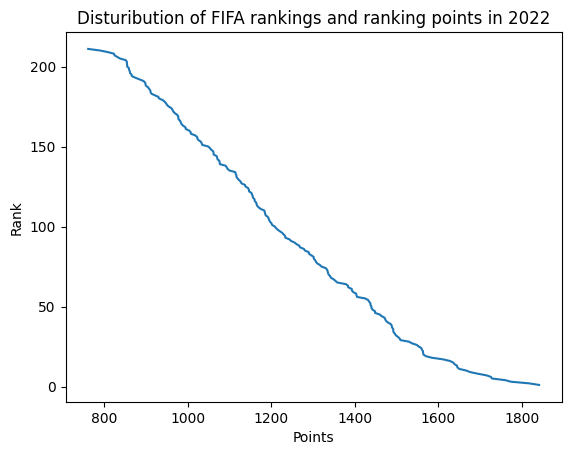

In [10]:
# overall distribution of FIFA rankings and ranking points in 2022
sns.lineplot(data=df,x='points',y='rank')
plt.title('Disturibution of FIFA rankings and ranking points in 2022')
plt.xlabel('Points')
plt.ylabel('Rank')
plt.show()

In [11]:
#teams were ranked in the top 10
top_teams_10=df.groupby('team')['rank'].max().sort_values(ascending=True).reset_index(name='rank')
print('The top 10 teams are: ')
top_teams_10.head(10)



The top 10 teams are: 


,team,rank
0,Brazil,1
1,Belgium,2
2,Argentina,3
3,France,4
4,England,5
5,Italy,6
6,Spain,7
7,Netherlands,8
8,Portugal,9
9,Denmark,10


In [12]:
# associations with the highest number of ranked teams
df.columns
association_count=df.groupby('association')['rank'].count().sort_values(ascending=False).reset_index(name='count')
association_count

,association,count
0,UEFA,55
1,CAF,54
2,AFC,46
3,CONCACAF,35
4,OFC,11
5,CONMEBOL,10


C:\Users\Dell\AppData\Local\Temp\ipykernel_13036\2733760568.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=association_count,x='association',y='count',palette='viridis')


Text(0.5, 0, 'Number of ranks')

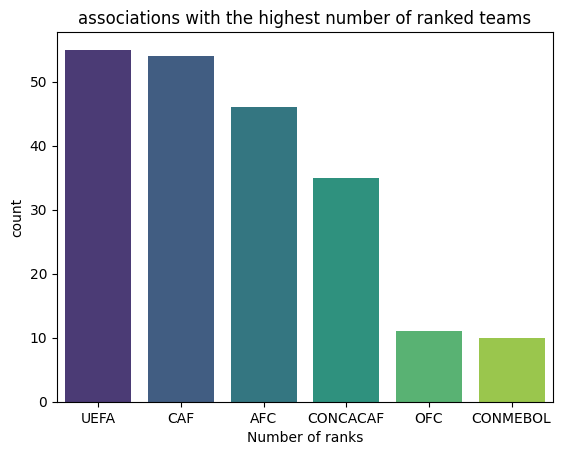

In [13]:
sns.barplot(data=association_count,x='association',y='count',palette='viridis')
plt.title("associations with the highest number of ranked teams")
plt.xlabel('Associations')
plt.xlabel('Number of ranks')

In [14]:
# Which associations had the best average FIFA ranking?
df.columns
avg_of_associations=df.groupby('association')['rank'].mean().sort_values(ascending=False).reset_index(name='avg')
avg_of_associations

,association,avg
0,OFC,165.000000
1,CONCACAF,137.571429
2,AFC,124.673913
3,CAF,109.833333
4,UEFA,68.236364
5,CONMEBOL,31.700000


C:\Users\Dell\AppData\Local\Temp\ipykernel_13036\4292424779.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_of_associations,x='association',y='avg',palette='Set1')


Text(0, 0.5, 'Average Ranking')

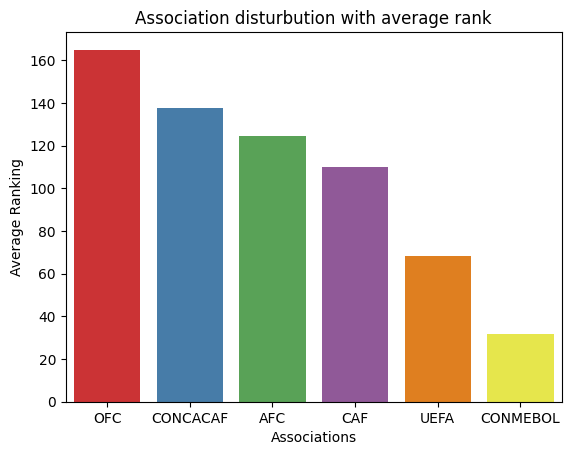

In [15]:
sns.barplot(data=avg_of_associations,x='association',y='avg',palette='Set1')
plt.title('Association disturbution with average rank')
plt.xlabel('Associations')
plt.ylabel('Average Ranking')

In [16]:
# Which associations had the highest average FIFA points?
highest_average_points=df.groupby('association')['points'].mean().sort_values(ascending=False).reset_index(name='Avg of Points')
highest_average_points

,association,Avg of Points
0,CONMEBOL,1554.936000
1,UEFA,1380.894364
2,CAF,1195.924815
3,AFC,1137.970000
4,CONCACAF,1094.896286
5,OFC,983.504545


Text(0, 0.5, 'Average of Points')

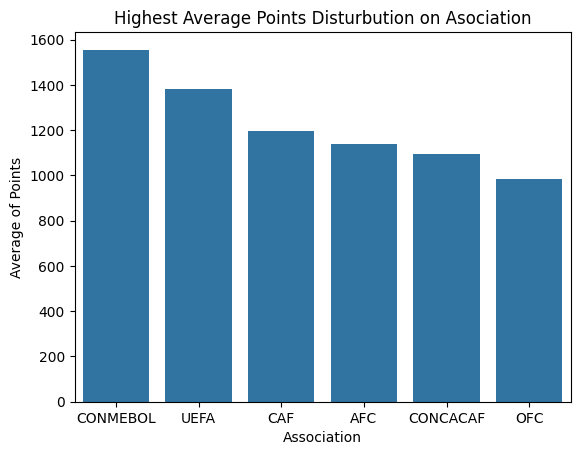

In [17]:
sns.barplot(data=highest_average_points,x='association',y='Avg of Points')
plt.title('Highest Average Points Disturbution on Asociation')
plt.xlabel('Association')
plt.ylabel('Average of Points')


In [18]:
# concentration of the FIFA points among the top-ranked teams
top_teams_10=df.groupby('team')['points'].mean().sort_values(ascending=False).reset_index(name='points')
print('The top 10 teams are: ')
top_teams_10.head(10)


The top 10 teams are: 


,team,points
0,Brazil,1841.30
1,Belgium,1816.71
2,Argentina,1773.88
3,France,1759.78
4,England,1728.47
5,Italy,1726.14
6,Spain,1715.22
7,Netherlands,1694.51
8,Portugal,1676.56
9,Denmark,1666.57


Text(0, 0.5, 'Top 10 Team')

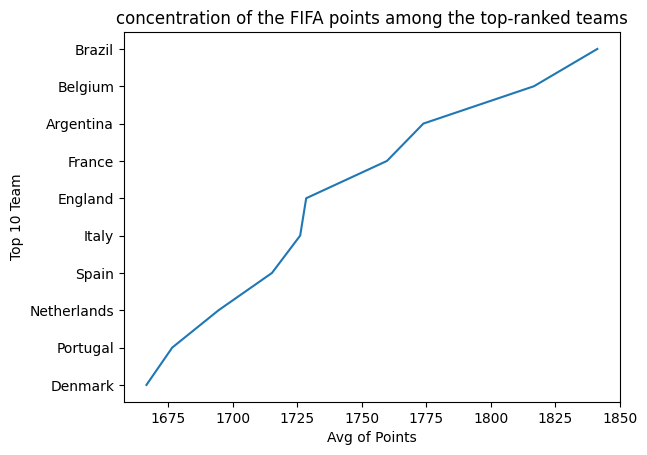

In [19]:
top=top_teams_10.head(10)
sns.lineplot(data=top,x='points',y='team')
plt.title('concentration of the FIFA points among the top-ranked teams')
plt.xlabel('Avg of Points')
plt.ylabel('Top 10 Team')

Ranking Movement Analysis

In [ ]:
# the top 10 teams with the biggest rank improvement.

df['rank_improvement']=df['previous_rank']-df['rank']
improved_teams=df[df['rank_improvement']>0]

top_10=(improved_teams.sort_values('rank_improvement',ascending=False).head(10))
print(top_10[['team','rank','previous_rank','rank_improvement']])



              team  rank  previous_rank  rank_improvement
39        Scotland    40             45                 5
122     Azerbaijan   123            128                 5
36         Algeria    37             41                 4
47   Côte d'Ivoire    48             52                 4
20          Serbia    21             25                 4
77         Georgia    78             82                 4
102     Mauritania   103            107                 4
138       Suriname   139            143                 4
121  Faroe Islands   122            125                 3
55         Finland    56             59                 3


In [35]:
#  top 10 teams with the biggest FIFA points increase.
df.columns
df['point_improvement']=df['previous_points']-df['points']
improved_points=df[df['point_improvement']>0]
top10=(improved_points.sort_values('point_improvement',ascending=False).head(10))
print(top10[['team','points','previous_points','point_improvement']])

                team   points  previous_points  point_improvement
64   North Macedonia  1358.51          1375.20              16.69
41            Norway  1473.04          1488.57              15.53
44           Türkiye  1460.14          1475.13              14.99
85           Curaçao  1278.64          1293.35              14.71
54          Slovakia  1425.59          1439.99              14.40
68        Montenegro  1341.03          1354.59              13.56
42          Cameroon  1471.44          1484.95              13.51
18             Wales  1569.82          1582.13              12.31
195    Liechtenstein   862.39           873.99              11.60
90             Benin  1247.47          1258.71              11.24


In [39]:
df.columns
# the top 10 teams with the biggest FIFA points increase.
df["points_improvement"]=df['points']-df['previous_points']
top_teams=df.sort_values('points_improvement',ascending=False).head(10)
print(top_teams[['team','points','previous_points','points_improvement']])

            team   points  previous_points  points_improvement
122   Azerbaijan  1146.72          1127.17               19.55
39      Scotland  1479.53          1462.96               16.57
173      Moldova   961.23           944.96               16.27
102   Mauritania  1197.58          1181.86               15.72
7    Netherlands  1694.51          1679.41               15.10
151    Indonesia  1033.90          1019.19               14.71
14   Switzerland  1635.92          1621.43               14.49
20        Serbia  1563.62          1549.53               14.09
11       Croatia  1645.64          1632.15               13.49
5          Italy  1726.14          1713.86               12.28


In [ ]:
# the top 10 teams with the biggest rank decline.
df["points_improvement"]=df['points']-df['previous_points']
top_teams=df.sort_values('points_improvement',ascending=True).head(10)
print(top_teams[['team','points','previous_points','points_improvement']])

                team   points  previous_points  points_improvement
64   North Macedonia  1358.51          1375.20              -16.69
41            Norway  1473.04          1488.57              -15.53
44           Türkiye  1460.14          1475.13              -14.99
85           Curaçao  1278.64          1293.35              -14.71
54          Slovakia  1425.59          1439.99              -14.40
68        Montenegro  1341.03          1354.59              -13.56
42          Cameroon  1471.44          1484.95              -13.51
18             Wales  1569.82          1582.13              -12.31
195    Liechtenstein   862.39           873.99              -11.60
90             Benin  1247.47          1258.71              -11.24


In [45]:
# teams that gained FIFA points but dropped in ranking.
gained_points_dropped_rank = df[
    (df['points'] > df['previous_points']) &
    (df['rank'] > df['previous_rank'])
]

print(gained_points_dropped_rank[
    ['team',
     'previous_rank',
     'rank',
     'previous_points',
     'points']
])



         team  previous_rank  rank  previous_points   points
72   Congo DR             72    73          1332.84  1333.92
106    Kosovo            106   107          1183.90  1187.01
109    Cyprus            108   110          1180.52  1183.82
123    Malawi            122   124          1144.77  1144.97


In [55]:

# Calculate change
gained_points_dropped_rank = gained_points_dropped_rank.copy()

gained_points_dropped_rank['Points_Gained'] = (
    gained_points_dropped_rank['points']
    - gained_points_dropped_rank['previous_points']
)

gained_points_dropped_rank['Rank_Drop'] = (
    gained_points_dropped_rank['rank']
    - gained_points_dropped_rank['previous_rank']
)

gained_points_dropped_rank = gained_points_dropped_rank.sort_values(
    'Points_Gained',
    ascending=False
)

print(gained_points_dropped_rank[
    ['team',
     'previous_rank',
     'rank',
     'Rank_Drop',
     'previous_points',
     'points',
     'Points_Gained']
])

             team  previous_rank  rank  Rank_Drop  previous_points   points  \
113    Mozambique            116   114         -2          1165.41  1165.22   
66   South Africa             68    67         -1          1350.55  1349.59   
129      Tanzania            131   130         -1          1121.91  1119.89   
88         Uganda             90    89         -1          1264.56  1260.69   

     Points_Gained  
113          -0.19  
66           -0.96  
129          -2.02  
88           -3.87  


In [54]:
#  teams that lost FIFA points but improved in ranking.

gained_points_dropped_rank = gained_points_dropped_rank = df[
    (df['points'] < df['previous_points']) &
    (df['rank'] < df['previous_rank'])
]

gained_points_dropped_rank =gained_points_dropped_rank .copy()


gained_points_dropped_rank['Points_Gained'] = (
    gained_points_dropped_rank['points']
    - gained_points_dropped_rank['previous_points']
)

gained_points_dropped_rank['Rank_Drop'] = (
    gained_points_dropped_rank['rank']
    - gained_points_dropped_rank['previous_rank']
)

gained_points_dropped_rank = gained_points_dropped_rank.sort_values(
    'Rank_Drop',
    ascending=False
)

print(gained_points_dropped_rank[
    ['team',
     'previous_rank',
     'rank',
     'Rank_Drop',
     'previous_points',
     'points',
     'Points_Gained']
])

             team  previous_rank  rank  Rank_Drop  previous_points   points  \
66   South Africa             68    67         -1          1350.55  1349.59   
88         Uganda             90    89         -1          1264.56  1260.69   
129      Tanzania            131   130         -1          1121.91  1119.89   
113    Mozambique            116   114         -2          1165.41  1165.22   

     Points_Gained  
66           -0.96  
88           -3.87  
129          -2.02  
113          -0.19  


In [52]:
# Teams with both rank improvement and points improvement

rank_points_improved = df[
    (df['rank'] < df['previous_rank']) &
    (df['points'] > df['previous_points'])
].copy()

# Calculate improvements
rank_points_improved['Positions_Improved'] = (
    rank_points_improved['previous_rank']
    - rank_points_improved['rank']
)

rank_points_improved['Points_Gained'] = (
    rank_points_improved['points']
    - rank_points_improved['previous_points']
)

# Sort by biggest rank improvement, then biggest points gained
rank_points_improved = rank_points_improved.sort_values(
    ['Positions_Improved', 'Points_Gained'],
    ascending=False
)

print(rank_points_improved[
    ['team',
     'previous_rank',
     'rank',
     'Positions_Improved',
     'previous_points',
     'points',
     'Points_Gained']
].head(10))

              team  previous_rank  rank  Positions_Improved  previous_points  \
122     Azerbaijan            128   123                   5          1127.17   
39        Scotland             45    40                   5          1462.96   
102     Mauritania            107   103                   4          1181.86   
20          Serbia             25    21                   4          1549.53   
77         Georgia             82    78                   4          1296.46   
36         Algeria             41    37                   4          1480.59   
47   Côte d'Ivoire             52    48                   4          1435.91   
138       Suriname            143   139                   4          1072.24   
173        Moldova            177   174                   3           944.96   
151      Indonesia            155   152                   3          1019.19   

      points  Points_Gained  
122  1146.72          19.55  
39   1479.53          16.57  
102  1197.58          15.72  

In [56]:
# teams with both rank improvement and points improvement

rank_points_improved = df[
    (df['rank'] < df['previous_rank']) &
    (df['points'] > df['previous_points'])
].copy()

# Calculate improvements
rank_points_improved['Positions_Improved'] = (
    rank_points_improved['previous_rank']
    - rank_points_improved['rank']
)

rank_points_improved['Points_Gained'] = (
    rank_points_improved['points']
    - rank_points_improved['previous_points']
)

# Sort by biggest rank improvement, then biggest points gained
rank_points_improved = rank_points_improved.sort_values(
    ['Positions_Improved', 'Points_Gained'],
    ascending=False
)

print(rank_points_improved[
    ['team',
     'previous_rank',
     'rank',
     'Positions_Improved',
     'previous_points',
     'points',
     'Points_Gained']
].head(10))

              team  previous_rank  rank  Positions_Improved  previous_points  \
122     Azerbaijan            128   123                   5          1127.17   
39        Scotland             45    40                   5          1462.96   
102     Mauritania            107   103                   4          1181.86   
20          Serbia             25    21                   4          1549.53   
77         Georgia             82    78                   4          1296.46   
36         Algeria             41    37                   4          1480.59   
47   Côte d'Ivoire             52    48                   4          1435.91   
138       Suriname            143   139                   4          1072.24   
173        Moldova            177   174                   3           944.96   
151      Indonesia            155   152                   3          1019.19   

      points  Points_Gained  
122  1146.72          19.55  
39   1479.53          16.57  
102  1197.58          15.72  

In [57]:
# teams with both rank decline and points decline.


rank_points_improved = df[
    (df['rank'] > df['previous_rank']) &
    (df['points'] < df['previous_points'])
].copy()

# Calculate improvements
rank_points_improved['Positions_Improved'] = (
    rank_points_improved['previous_rank']
    - rank_points_improved['rank']
)

rank_points_improved['Points_Gained'] = (
    rank_points_improved['points']
    - rank_points_improved['previous_points']
)

# Sort by biggest rank improvement, then biggest points gained
rank_points_improved = rank_points_improved.sort_values(
    ['Positions_Improved', 'Points_Gained'],
    ascending=False
)

print(rank_points_improved[
    ['team',
     'previous_rank',
     'rank',
     'Positions_Improved',
     'previous_points',
     'points',
     'Points_Gained']
].head(10))

                       team  previous_rank  rank  Positions_Improved  \
57   Bosnia and Herzegovina             57    58                  -1   
60                    Ghana             60    61                  -1   
56                Venezuela             56    57                  -1   
198              Seychelles            198   199                  -1   
159               Singapore            159   160                  -1   
126                    Togo            126   127                  -1   
136                  Rwanda            136   137                  -1   
6                     Spain              6     7                  -1   
13                  Uruguay             13    14                  -1   
81                  Bolivia             81    82                  -1   

     previous_points   points  Points_Gained  
57           1403.98  1403.51          -0.47  
60           1393.47  1393.00          -0.47  
56           1405.17  1404.37          -0.80  
198           860.4